In [12]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget
%matplotlib widget

In [13]:
# # 1. Paramètres initiaux
# noise_params = {'std': 0.00, 'mean': 0.0}
# n_iterations = 0

# # 2. Préparation du premier échantillon (initialisation)
# test_samples = get_data_samples(data_module, n_samples_test, split="train")
# # On initialise 'reshape' avec les attributs de départ
# current_attr = test_samples[frozenset({'attr', 'v_latents'})]['attr']

# # On utilise torch.no_grad() pour éviter l'accumulation du graphe de calcul (fuite mémoire)
# with torch.no_grad():
#     for i in range(n_iterations):
#         # Préparation du dictionnaire pour l'encodage
#         samples_dict = {frozenset({'attr', 'v_latents'}): {"attr": current_attr}}
        
#         # Encodage
#         unimodal_latents = global_workspace.encode_domains(samples_dict)
#         gw_latents = global_workspace.encode(unimodal_latents)
#         gw_latents_attr = gw_latents[frozenset({'attr', 'v_latents'})]['attr']

#         # Ajout du bruit
#         noise = torch.randn_like(gw_latents_attr) * noise_params['std'] + noise_params['mean']
#         gw_latents_attr_noisy = gw_latents_attr + noise

#         # Décodage vers image puis ré-encodage (boucle de reconstruction)
#         decoded_image = global_workspace.decode({'attr': gw_latents_attr_noisy})['attr']['v_latents']
        
#         # Encodage de l'image décodée
#         img_input = {'v_latents': {'v_latents': decoded_image}}
#         gw_latent_from_img = global_workspace.encode(img_input)['v_latents']['v_latents']

#         # Fusion des deux représentations latentes
#         fusion = 0.5 * gw_latents_attr_noisy + 0.5 * gw_latent_from_img

#         # Décodage de la fusion vers les attributs
#         decoded_attr_from_fusion = global_workspace.decode({'fusion': fusion})['fusion']['attr']

#         # Transformation (logits -> probas + split)
#         # On extrait ici le résultat pour l'itération suivante
#         current_attr = split_softmax_category_attributes(decoded_attr_from_fusion)

In [14]:
project_name = "syn"
condition = "shape_124"
data = "biased_00"
checkpoint_epoch = 0
n_samples_test = 200

# truth attr et n_iterations = 0: traduction attr vers image
# truth v_latents et n_iterations = 0: demi cycle v_latents
# truth v_latents, n_iterations = 1, p_truth = 0: cycle v_latents par attribut
truth = "v_latents"
proportion_truth = 0.0
split = "test"
n_iterations = 1
noise_params = {'std': 0.0, 'mean': 0.0}


In [15]:
illusion = "v_latents"
if truth == "v_latents":
    illusion = "attr"

experiment_name = get_experiment_name(condition, "biased_00", 0)
modules = get_setup_modules('syn', experiment_name)

global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
unimodal_latents = global_workspace.encode_domains(test_samples)
gw_latents = global_workspace.encode(unimodal_latents)[frozenset({'attr', 'v_latents'})]
latent_truth = gw_latents[truth]
latent_fusion = latent_truth

# à partir de l'input de la modalité truth, je traduis dans la modalité illusion, puis je fusionne l'encodage de l'input truth original et de illusion traduit.
# à partir de la fusion obtenue, je traduis en illusion, puis je fusionne l'encodage de l'input truth original et de la fusion précédente.
with torch.no_grad():
    for i in range(n_iterations):
        noise = torch.randn_like(latent_fusion) * noise_params['std'] + noise_params['mean']
        latent_fusion = latent_fusion + noise

        traduction = global_workspace.decode({truth: latent_fusion})
        unimodal_illusion = traduction[truth][illusion]
        if illusion == "attr":
            unimodal_illusion = split_softmax_category_attributes(unimodal_illusion)

        sample = {frozenset({'attr', 'v_latents'}): {illusion: unimodal_illusion}}
        l = global_workspace.encode_domains(sample)
        
        latent_illusion = global_workspace.encode(l)[frozenset({'attr','v_latents'})][illusion].detach()
        
        latent_fusion = ((1 - proportion_truth) * latent_illusion + proportion_truth * latent_truth).detach()

        print(f"Iteration {i}: fusion mean = {latent_fusion.mean().item()}")

image_finale = global_workspace.decode({'fusion': latent_fusion})['fusion']['v_latents']
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods['v_latents'])
image_finale_rgb = visual_module.decode_images(image_finale)

torch.cuda.empty_cache()

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/shape_124_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/shape_124_biased_00/checkpoints/last.ckpt
Iteration 0: fusion mean = 0.27996423840522766


In [16]:
# pct d'erreur de catégorisation
attr_final = global_workspace.decode({'fusion': latent_fusion})['fusion']['attr']
cat_final = torch.argmax(split_softmax_category_attributes(attr_final)[0], dim=1)
cat_truth = torch.argmax(test_samples[frozenset({'attr', 'v_latents'})]['attr'][0], dim=1)
sum(cat_final != cat_truth)/ n_samples_test

tensor(0.0050, device='cuda:0')

In [17]:
attribut = test_samples[frozenset(["v_latents", "attr"])]["attr"]
original_attr = torch.cat((attribut[0], attribut[1]), dim=1)

reconstructed_attr = split_softmax_category_attributes(attr_final)
reconstructed_attr_col = torch.cat((reconstructed_attr[0], reconstructed_attr[1]), dim=1).detach()
metrics = analyze_attribute_drift(original_attr, reconstructed_attr_col)
print(metrics)

   Attribute_Index  Mean_Absolute_Error Drift_Percentage
0                0             0.000253            0.03%
1                1             0.005002            0.50%
2                2             0.005255            0.53%
3                3             0.225993           22.60%
4                4             0.262751           26.28%
5                5             0.483515           48.35%
6                6             0.246293           24.63%
7                7             0.215430           21.54%


In [18]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

#decoded_images_rgb = visual_module.decode_images(decoded_image)
original_images = test_samples[frozenset({'attr', 'v_latents'})]['v_latents']
original_images_rgb = visual_module.decode_images(original_images)
cat = test_samples[frozenset({'attr', 'v_latents'})]['attr']
colors_np = get_samples_rgb({"train_images": None, "images_decoded": image_finale_rgb}, 'decoded_edge')

import matplotlib.pyplot as plt



/home/lucas/gwsyn/syn_project/utils_color_analysis.py:148: UserWarning: Empty mask detected; using full image for color extraction
  warnings.warn("Empty mask detected; using full image for color extraction")


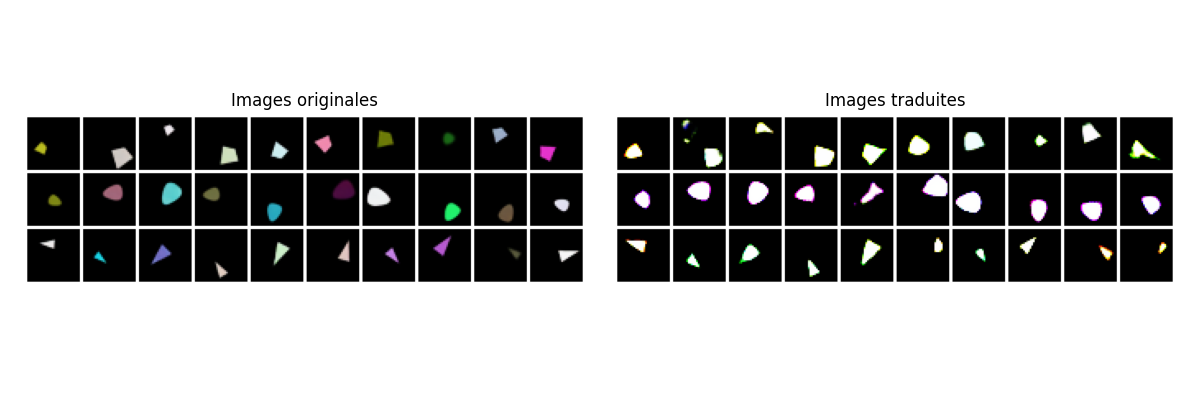

In [19]:

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat[0], 10), get_n_per_category(image_finale_rgb, cat[0], 10))
plt.show()



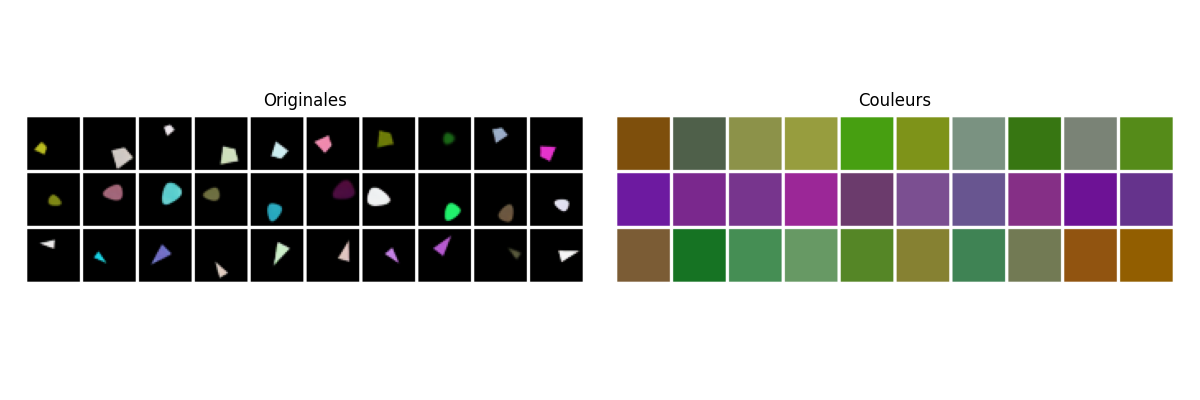

In [20]:
colors_tensor =torch.from_numpy(colors_np).to('cuda')
colors_p = colors_tensor[:, [0, 1, 2]]

fig = plot_original_color_comparison(get_n_per_category(original_images_rgb, cat[0], 10), get_n_per_category(colors_p, cat[0], 10))
plt.show()


In [21]:
# est ce qu'on peut reconnaitre la catégorie avec seulement la couleur de l'espace latent attribut?
scaler = StandardScaler()
model = LogisticRegression(max_iter=1000)

X = colors_np 
y = cat[0].argmax(dim=1).detach().cpu().numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")
print("\nDétails par catégorie :")
print(classification_report(y_test, y_pred))

Précision globale (Accuracy) : 65.00%

Détails par catégorie :
              precision    recall  f1-score   support

           0       0.55      0.46      0.50        13
           1       0.91      0.91      0.91        11
           2       0.56      0.62      0.59        16

    accuracy                           0.65        40
   macro avg       0.67      0.67      0.67        40
weighted avg       0.65      0.65      0.65        40



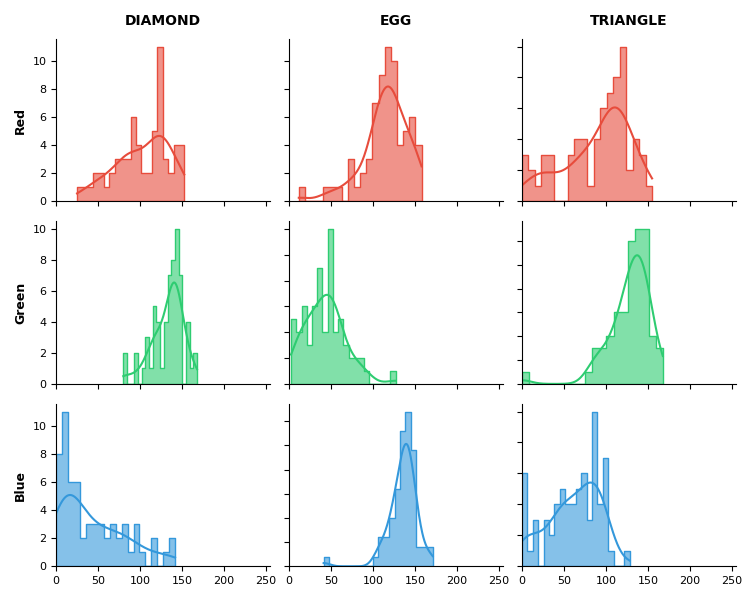

In [22]:


fig = plot_rgb_distribution(colors_np, y, n_bins=20)
plt.show()

In [23]:
del original_images_rgb
del image_finale_rgb
torch.cuda.empty_cache()